# データの確認

In [1]:
# ライブラリのインポート
import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as pl
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import scipy.special

In [2]:
data = pd.read_csv('insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
data.shape

(1338, 7)

In [4]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
# カテゴリカル変数のラベリング
from sklearn.preprocessing import LabelEncoder
# 女性を1,男性を0とする
le = LabelEncoder()
le.fit(data.sex.drop_duplicates()) 
data.sex = le.transform(data.sex)
# 喫煙者を1,非喫煙者を0とする
le.fit(data.smoker.drop_duplicates()) 
data.smoker = le.transform(data.smoker)
# 地域
le.fit(data.region.drop_duplicates()) 
data.region = le.transform(data.region)

In [6]:
data.describe()

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,1.515695,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.104885,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010


In [7]:
data.corr()['charges'].sort_values()

region     -0.006208
sex         0.057292
children    0.067998
bmi         0.198341
age         0.299008
smoker      0.787251
charges     1.000000
Name: charges, dtype: float64

<Axes: >

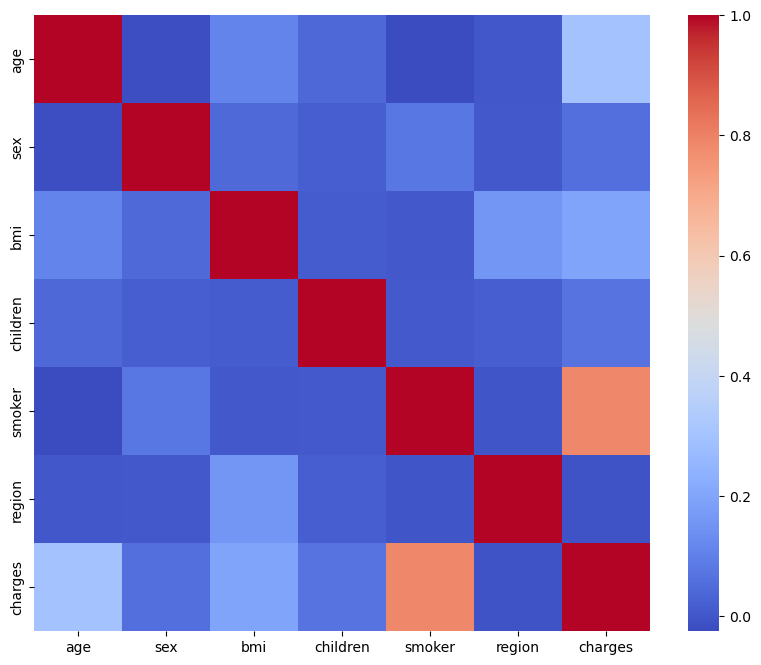

In [8]:
f, ax = pl.subplots(figsize=(10, 8))
corr = data.corr()
sns.heatmap(corr, square=True,cmap="coolwarm", ax=ax)

年齢,BMI,喫煙者の相関係数が高いのは大方予想通りである。

(array([536., 398., 129.,  86.,  35.,  59.,  57.,  32.,   2.,   4.]),
 array([ 1121.8739  ,  7386.729311, 13651.584722, 19916.440133,
        26181.295544, 32446.150955, 38711.006366, 44975.861777,
        51240.717188, 57505.572599, 63770.42801 ]),
 <BarContainer object of 10 artists>)

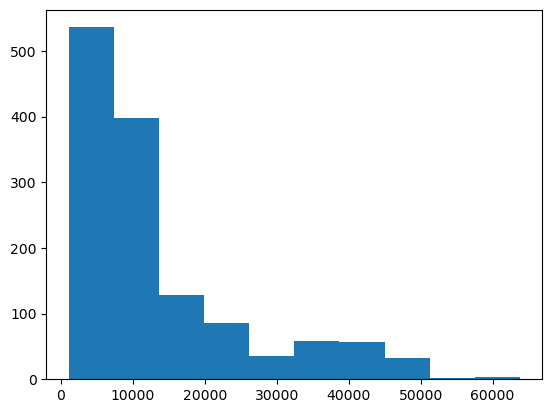

In [9]:
# 医療費の分布
import matplotlib.pyplot as plt
plt.hist(data['charges'])

かなり偏っているため対数変換の必要性がある。

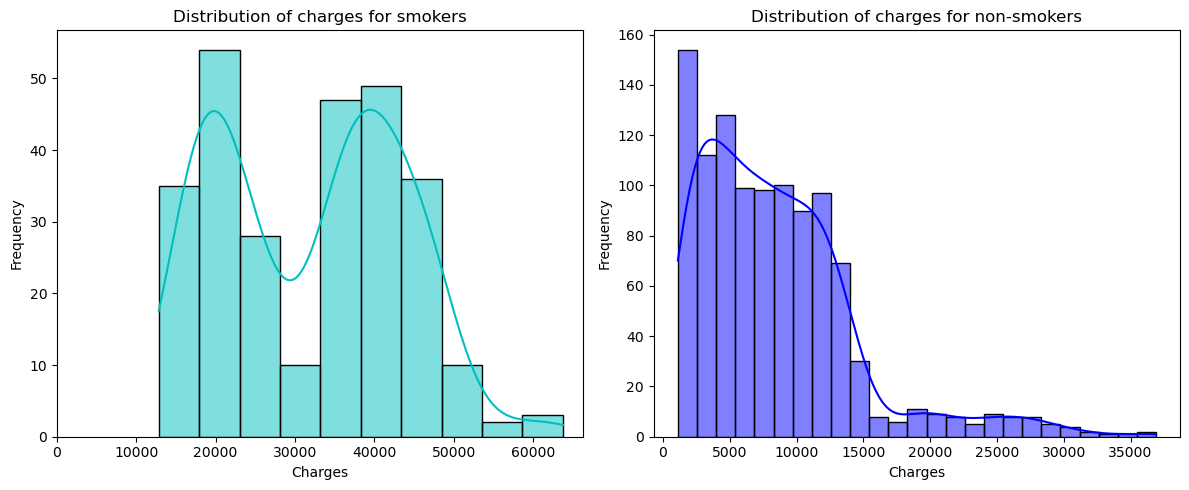

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# 喫煙者の医療費の分布
sns.histplot(data[data['smoker'] == 1]['charges'], color='c', kde=True, ax=axes[0])
axes[0].set_title('Distribution of charges for smokers')
axes[0].set_xlabel('Charges')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(left=0)  # X軸の下限を0に設定

# 非喫煙者の医療費の分布
sns.histplot(data[data['smoker'] == 0]['charges'], color='b', kde=True, ax=axes[1])
axes[1].set_title('Distribution of charges for non-smokers')
axes[1].set_xlabel('Charges')
axes[1].set_ylabel('Frequency')
axes[0].set_xlim(left=0)  # X軸の下限を0に設定

plt.tight_layout()
plt.show()

喫煙者の医療費の方が高く、また2峰性がわかる。

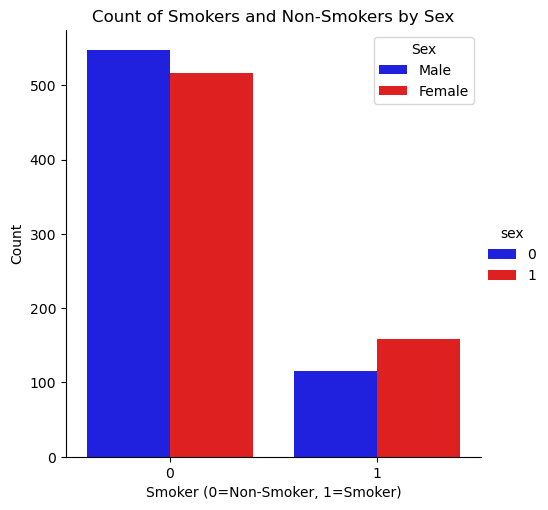

In [11]:
# 喫煙者と性別の関係
sns.catplot(x="smoker", kind="count", hue='sex', palette=["blue", "red"], data=data)
plt.title('Count of Smokers and Non-Smokers by Sex')
plt.xlabel('Smoker (0=Non-Smoker, 1=Smoker)')
plt.ylabel('Count')
plt.legend(title='Sex', labels=['Male', 'Female'])
plt.show()

やはり男性の方が喫煙者が多い。

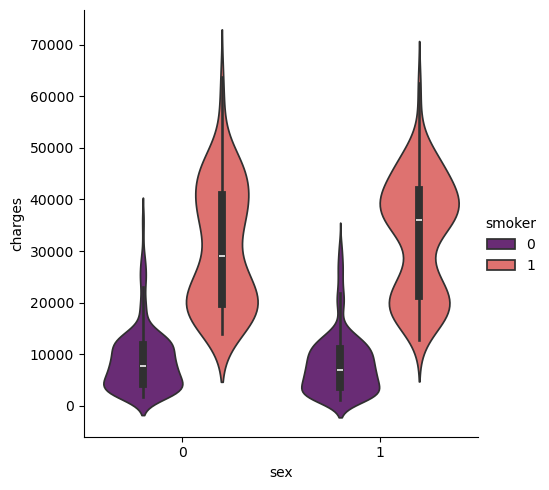

In [12]:
# 性別・喫煙者ごとの医療費の分布
sns.catplot(x="sex", y="charges", hue="smoker",
            kind="violin", data=data, palette = 'magma')

性別の差でなく喫煙者か否かで差があることがわかる。

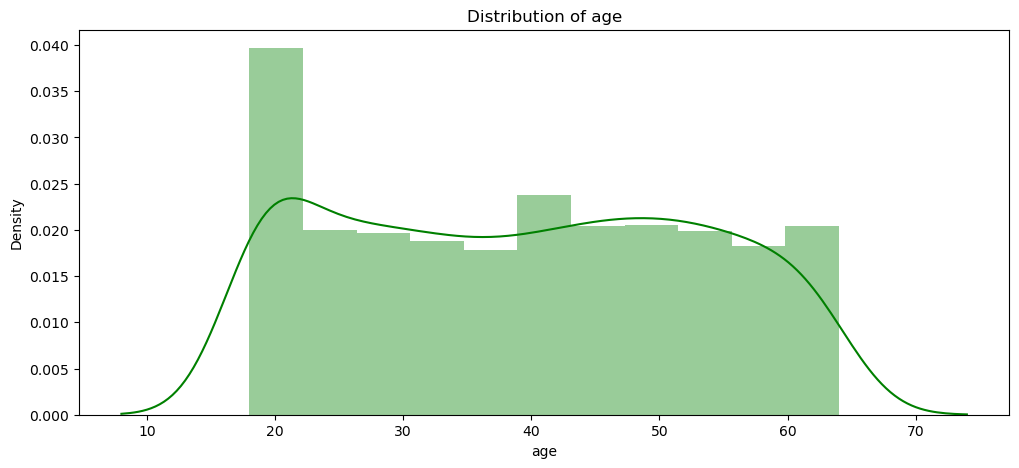

In [13]:
# 年齢の分布
pl.figure(figsize=(12,5))
pl.title("Distribution of age")
ax = sns.distplot(data["age"], color = 'g')

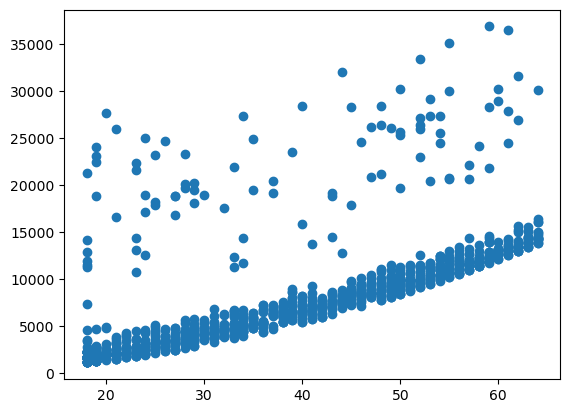

In [14]:
# 非喫煙者の年齢と医療費の散布図
plt.scatter(x="age", y="charges", data = data[(data.smoker == 0)])

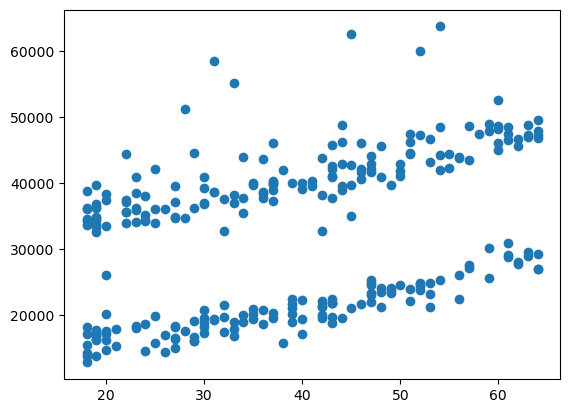

In [15]:
# 喫煙者の年齢と医療費の散布図
plt.scatter(x="age", y="charges", data = data[(data.smoker == 1)])

Text(0.5, 1.0, 'Smokers and non-smokers')

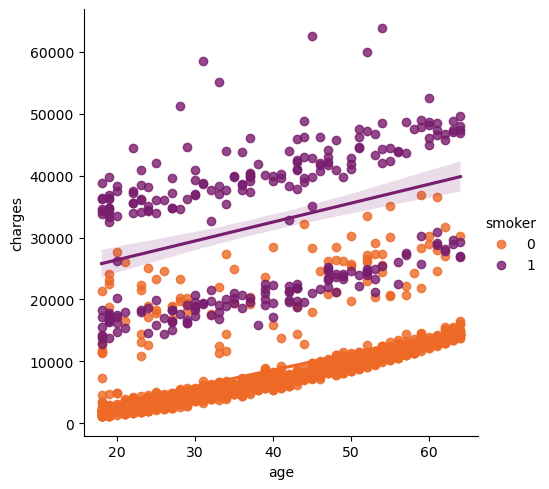

In [16]:
# 年齢と医療費の散布図
sns.lmplot(x="age", y="charges", hue="smoker", data=data, palette = 'inferno_r')
ax.set_title('Smokers and non-smokers')

どちらも年齢とともに医療費が上昇するが、喫煙者は2つの分布に分かれていることがわかる。

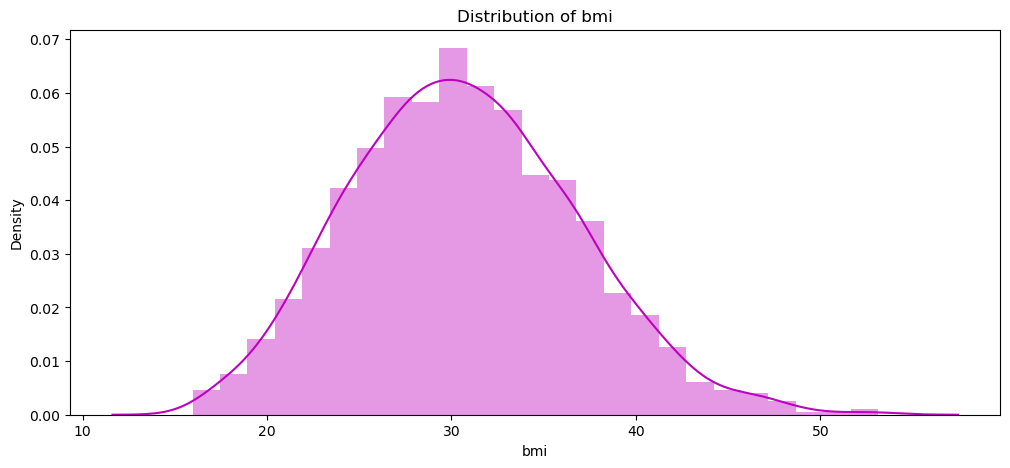

In [17]:
# bmiの分布
plt.figure(figsize=(12,5))
plt.title("Distribution of bmi")
ax = sns.distplot(data["bmi"], color = 'm')

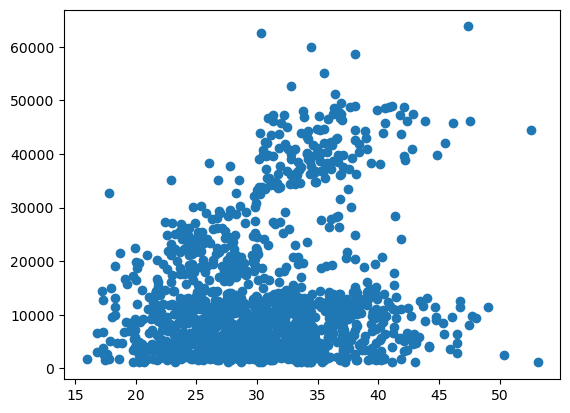

In [18]:
# BMIと医療費の散布図
plt.scatter(x="bmi", y="charges", data = data)

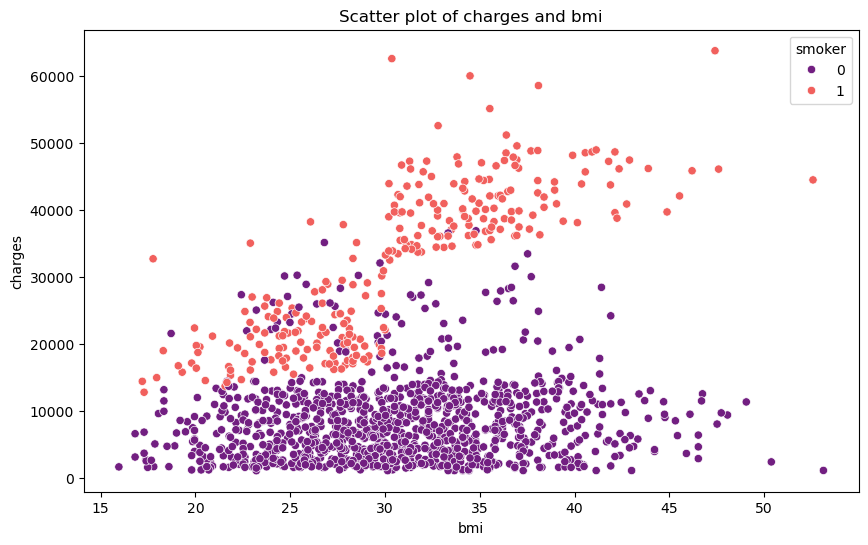

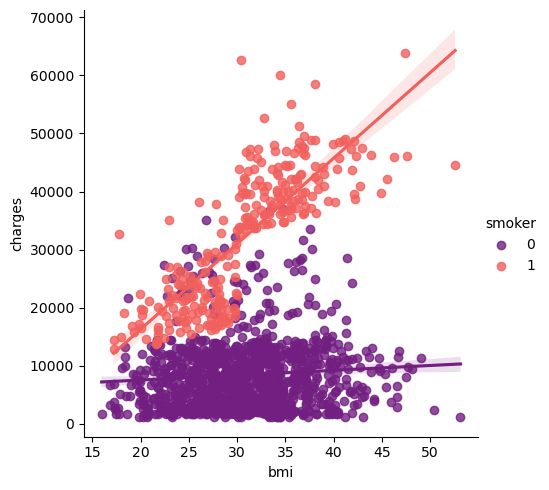

In [19]:
plt.figure(figsize=(10,6))
ax = sns.scatterplot(x='bmi',y='charges',data=data,palette='magma',hue='smoker')
ax.set_title('Scatter plot of charges and bmi')

sns.lmplot(x="bmi", y="charges", hue="smoker", data=data, palette = 'magma')

喫煙者か否かで散布図の挙動が異なる。

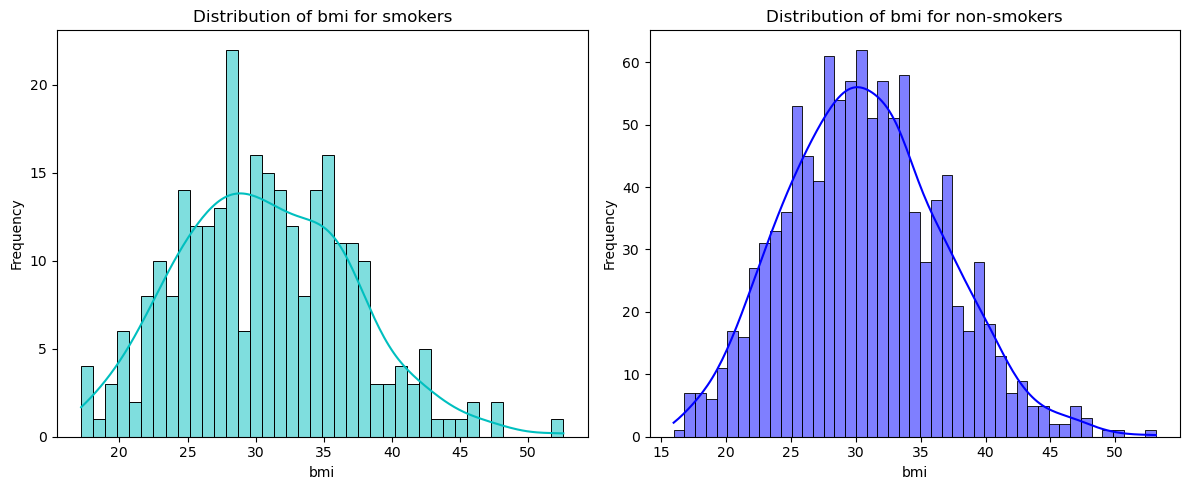

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
# 喫煙者のBMIの分布
sns.histplot(data[data['smoker'] == 1]['bmi'], color='c', kde=True, ax=axes[0],bins=40)
axes[0].set_title('Distribution of bmi for smokers')
axes[0].set_xlabel('bmi')
axes[0].set_ylabel('Frequency')
# X軸の下限を0に設定

# 非喫煙者のBMIの分布
sns.histplot(data[data['smoker'] == 0]['bmi'], color='b', kde=True, ax=axes[1],bins=45)
axes[1].set_title('Distribution of bmi for non-smokers')
axes[1].set_xlabel('bmi')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

喫煙者は肥満(BMI>30というよくある指数)で分布を分けることができそうである。
喫煙と肥満の交互作用効果を作成する。

In [21]:
# BMI 30以上かどうかのカラム追加
data['bmi_over30'] = (data['bmi'] >= 30).astype(int)

# 交互作用追加
data['bmi_over30_smoker'] = data['bmi_over30'] * data['smoker']
data['bmi_under30_smoker'] = (1 - data['bmi_over30']) * data['smoker']
data['bmi_over30_nosmoker'] = data['bmi_over30'] * (1 - data['smoker'])
data['bmi_under30_nosmoker'] = (1 - data['bmi_over30']) * (1 - data['smoker'])

Text(0.5, 1.0, 'Smokers and non-smokers')

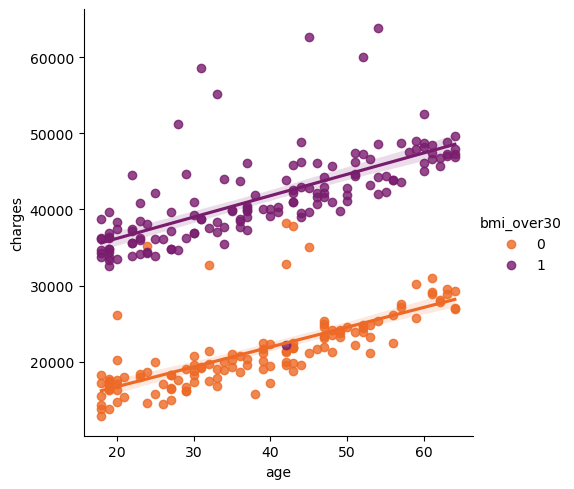

In [22]:
# 喫煙者の年齢と医療費の散布図
sns.lmplot(x="age", y="charges", hue="bmi_over30", data=data[data['smoker'] == 1], palette = 'inferno_r')
ax.set_title('Smokers and non-smokers')

これで先ほどの喫煙者の2つの挙動をとらえることができた。

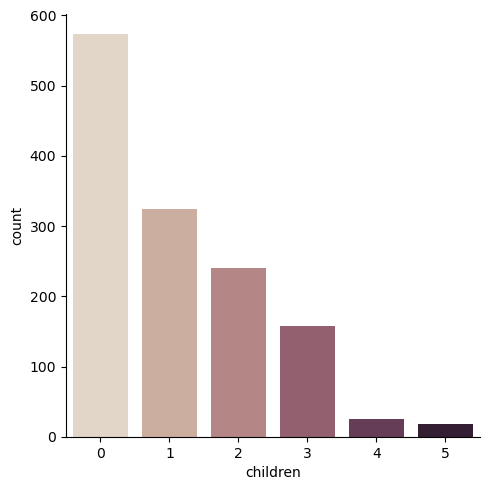

In [23]:
# 子供数の分布
sns.catplot(x="children", kind="count", palette="ch:.25", data=data)

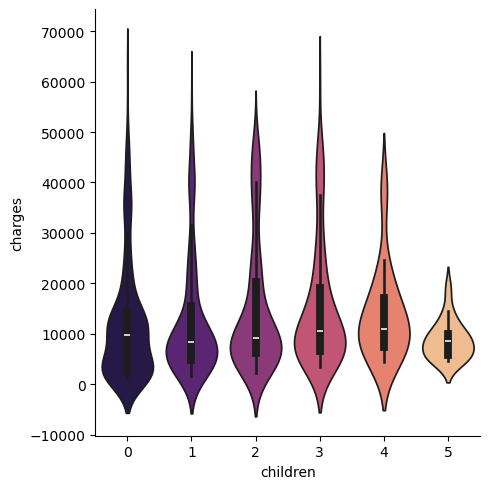

In [24]:
# 子供数ごとの医療費の分布
sns.catplot(x="children", y="charges",
            kind="violin", data=data, palette = 'magma')

Text(0.5, 1.0, 'Smokers and non-smokers who have childrens')

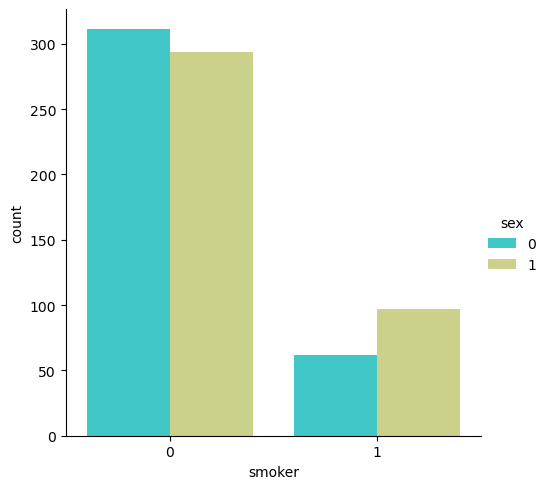

In [25]:
sns.catplot(x="smoker", kind="count", palette="rainbow",hue = "sex",
            data=data[(data.children > 0)])
ax.set_title('Smokers and non-smokers who have childrens')

Text(0.5, 1.0, 'Smokers and non-smokers who have childrens')

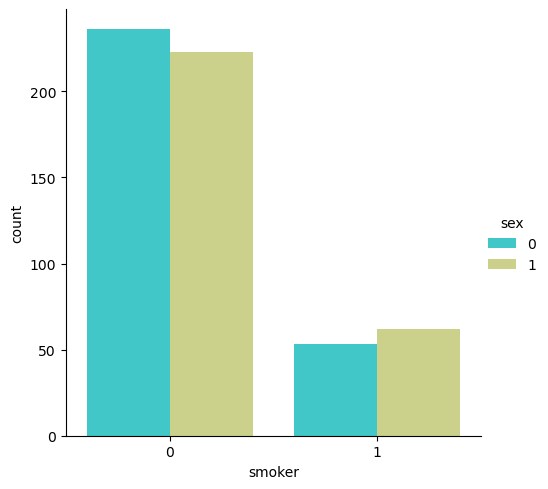

In [26]:
sns.catplot(x="smoker", kind="count", palette="rainbow",hue = "sex",
            data=data[(data.children == 0)])
ax.set_title('Smokers and non-smokers who have childrens')

子供がいるかいないかで喫煙者の割合に変化あることがわかる。子供数を子供の有無という変数を置き換える。

In [27]:
# children列を0か1の値で置き換える
data['children'] = (data['children'] > 0).astype(int)

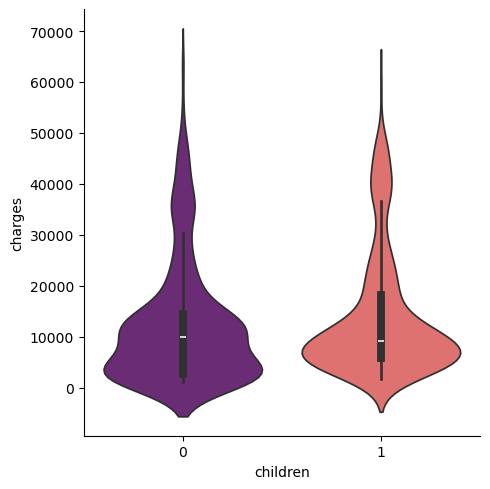

In [28]:
# 子供数ごとの医療費の分布
sns.catplot(x="children", y="charges",
            kind="violin", data=data, palette = 'magma')

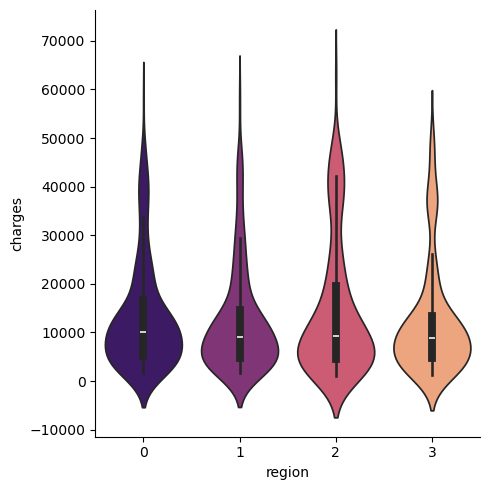

In [29]:
# 地域ごとの医療費の分布
sns.catplot(x="region", y="charges",
            kind="violin", data=data, palette = 'magma')

地域による差はあまり見られないので考えなくてよさそう。

(array([ 46., 105., 101., 155., 198., 283., 156., 123., 115.,  56.]),
 array([ 7.02275569,  7.42678461,  7.83081352,  8.23484244,  8.63887136,
         9.04290027,  9.44692919,  9.8509581 , 10.25498702, 10.65901594,
        11.06304485]),
 <BarContainer object of 10 artists>)

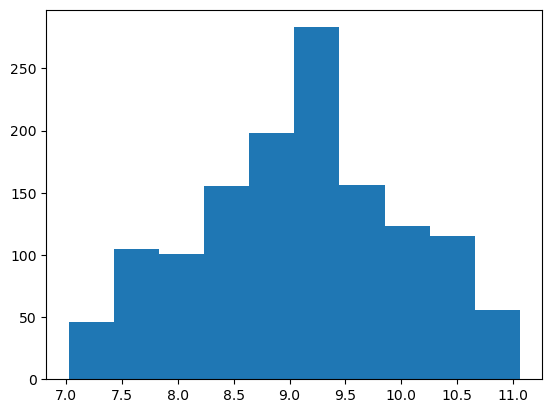

In [30]:
# 医療費を対数変換
data['charges'] = np.log(data['charges'])
plt.hist(data['charges'])

In [31]:
# 数値データを正規化
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data[['age', 'bmi', 'charges']] = scaler.fit_transform(data[['age', 'bmi', 'charges']])

In [32]:
data

,age,sex,bmi,children,smoker,region,charges,bmi_over30,bmi_over30_smoker,bmi_under30_smoker,bmi_over30_nosmoker,bmi_under30_nosmoker
0,0.021739,0,0.321227,0,1,3,0.671096,0,0,1,0,0
1,0.000000,1,0.479150,1,0,2,0.106563,1,0,0,1,0
2,0.217391,1,0.458434,1,0,2,0.341011,1,0,0,1,0
3,0.326087,1,0.181464,0,0,1,0.736417,0,0,0,0,1
4,0.304348,1,0.347592,0,0,1,0.306275,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.695652,1,0.403820,1,0,1,0.555877,1,0,0,1,0
1334,0.000000,0,0.429379,0,0,0,0.167357,1,0,0,1,0
1335,0.000000,0,0.562012,0,0,2,0.092438,1,0,0,1,0
1336,0.065217,0,0.264730,0,0,3,0.144077,0,0,0,0,1


# モデル比較

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

# 説明変数と目的変数を選択
X = data.drop(['charges'], axis = 1)
y = data.charges

# シード値
seed=42

# データの分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# モデルの構築と学習
models = [
    LinearRegression(),
    Ridge(random_state=seed),
    Lasso(random_state=seed),
    DecisionTreeRegressor(random_state=seed),
    RandomForestRegressor(random_state=seed),
    XGBRegressor(random_state=seed),
    LGBMRegressor(random_state=seed)
]

# 結果を保存するためのデータフレームを作成
results = pd.DataFrame(columns=['Model', 'MSE'])

# 各モデルに対して学習と評価を行うループ
for model in models:
    model_name = model.__class__.__name__  # モデルの名前を取得
    model.fit(X_train, y_train)  # モデルの学習
    y_pred = model.predict(X_test)  # 予測
    
    mse = mean_squared_error(y_test, y_pred)  # 平均二乗誤差を計算
    
    # 結果をデータフレームに登録
    results = pd.concat([results, pd.DataFrame({'Model': [model_name], 'MSE': [mse]})], ignore_index=True)

# MSEによって結果をソート
results = results.sort_values(by='MSE')

# 結果を出力
display(results)

  File "C:\Users\maeda\anaconda3\envs\kaggle\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 322
[LightGBM] [Info] Number of data points in the train set: 1070, number of used features: 11
[LightGBM] [Info] Start training from score 0.517430


,Model,MSE
4,RandomForestRegressor,0.009136
6,LGBMRegressor,0.009594
0,LinearRegression,0.010170
1,Ridge,0.010191
5,XGBRegressor,0.010328
3,DecisionTreeRegressor,0.016091
2,Lasso,0.055409


適当な設定でもかなり良い精度で予測できている。
因果関係の考察を行うなら線形回帰モデルで十分ではないだろうか。

# 線形回帰モデル

LinearRegressionではp値などの出力はできないのでstatsmodelsを用いる。

In [34]:
import statsmodels.api as sm

# 説明変数と目的変数を選択
X = data.drop(['charges','bmi','region'], axis = 1)
X = sm.add_constant(X)  # 切片（バイアス）項を追加
y = data.charges

# OLS回帰モデルの作成とフィット
model = sm.OLS(y, X)
results = model.fit()

# 結果の表示
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     791.3
Date:                Thu, 20 Jun 2024   Prob (F-statistic):               0.00
Time:                        23:06:50   Log-Likelihood:                 1098.6
No. Observations:                1338   AIC:                            -2183.
Df Residuals:                    1331   BIC:                            -2147.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.2029 

決定係数は0.781ですべての変数が有意であることがわかる。

想定通り年齢,喫煙,喫煙と肥満の交互作用が医療費に大きく影響を与えていることがわかる。

# 決定木モデル

In [63]:
train,test = train_test_split(data, test_size=0.2, random_state=seed)
X_test = data.drop(['charges'], axis = 1)
y_test = data.charges
df = train
df.reset_index(drop=True, inplace=True)  # 既存のインデックスを削除
df

,age,sex,bmi,children,smoker,region,charges,bmi_over30,bmi_over30_smoker,bmi_under30_smoker,bmi_over30_nosmoker,bmi_under30_nosmoker
0,0.608696,0,0.107345,1,0,1,0.520639,0,0,0,0,1
1,0.630435,0,0.224913,0,0,0,0.502226,0,0,0,0,1
2,0.739130,0,0.239440,0,0,2,0.788359,0,0,0,0,1
3,0.456522,0,0.493947,1,0,2,0.504022,1,0,0,1,0
4,0.782609,0,0.148238,1,0,1,0.596184,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1065,0.000000,0,0.414044,1,0,0,0.347149,1,0,0,1,0
1066,0.456522,0,0.212806,1,0,2,0.503603,0,0,0,0,1
1067,0.869565,1,0.247915,0,0,0,0.585144,0,0,0,0,1
1068,0.413043,0,0.851224,1,1,3,0.919762,1,1,0,0,0


In [44]:
num_features = ['age','bmi']
cat_features = ['sex','children','smoker','region','bmi_over30','bmi_over30_smoker','bmi_under30_smoker','bmi_over30_nosmoker','bmi_under30_nosmoker']

In [37]:
import os
import gc
import re
import ast
import sys
import copy
import json
import time
import math
import shutil
import string
import pickle
import random
import joblib
import itertools
from joblib import Parallel, delayed
from pathlib import Path
import warnings
import torch
warnings.filterwarnings("ignore")

import scipy as sp
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, GroupKFold, KFold
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

In [38]:
# seed固定
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(seed=42)

def get_kfold(train, n_splits, seed):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    generator = kf.split(train)
    fold_series = []
    for fold, (idx_train, idx_valid) in enumerate(generator):
        fold_series.append(pd.Series(fold, index=idx_valid))
    fold_series = pd.concat(fold_series).sort_index()
    return fold_series

In [49]:
# 5fold交差検証。再現性確保のためにseed固定
class CFG:
    seed = 42
    n_fold = 5

In [67]:
fold = get_kfold(df,CFG.n_fold, CFG.seed)
df['fold'] = fold

In [41]:
# ====================================================
# Model
# ====================================================
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.utils.extmath import softmax
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from sklearn.ensemble import RandomForestClassifier as rfc
from sklearn.ensemble import RandomForestRegressor as rfr

import optuna
optuna.logging.disable_default_handler()


class TabularModel:
    def __init__(
        self,
        model,
        param,
        n_fold,
        train_df,
        num_features,
        cat_features,
        target_col,
        num_class=1,
        output_dir='./',
        objective='regression',
    ):
        super().__init__()
        assert objective in ["regression", "classification"], 'SELECT model from ["regression", "classification"]'

        """
        引数
        model : 'LGB'か'XGB'か'CAT', または'RF'を選ぶ
        param : モデルのパラメータ
        n_fold : foldの数
        train_df : trainデータ
        num_features : 数値の特徴量
        cat_features : カテゴリの特徴量
        target_col : targetのカラム名
        num_class : 分類時のクラス数（回帰は1）
        output_dir : モデルの保存先
        objectibe : 回帰なのか分類なのかを指定
        """

        self.model = model
        self.param = param
        self.n_fold = n_fold
        self.num_round = 100000
        self.verbose_eval = 100
        self.early_stopping_rounds = 100
        self.num_class = num_class
        if num_class == 1:
            self.oof = np.zeros(len(train_df))
        elif num_class > 1:
            self.oof = np.zeros((len(train_df), num_class))
        self.num_features = num_features
        self.cat_features = cat_features
        self.features = num_features + cat_features
        self.target = train_df[target_col]
        self.objective = objective
        self.output_dir = output_dir


    # モデルのスコアを確認する
    def get_score(self, y_true, y_pred):
        """Define scoring function"""
        score = np.sqrt(mean_squared_error(y_true, y_pred))
        return score

    def _clf_train(self, clf, param, train_df, trn_idx, val_idx):
        X_tr, y_tr = train_df.iloc[trn_idx][self.features], self.target.iloc[trn_idx].values
        X_val, y_val = train_df.iloc[val_idx][self.features], self.target.iloc[val_idx].values
        clf.fit(X_tr, y_tr)
        if self.objective == 'regression':
            self.oof[val_idx] = clf.predict(X_val)
        elif self.objective == 'classification':
            probs = softmax(clf.decision_function(X_val))
            self.oof[val_idx] = probs
        return clf, None

    def _lgb_train(self, param, train_df, trn_idx, val_idx):
        feature_importance_df = pd.DataFrame()
        feature_importance_df["feature"] = self.features

        trn_data = lgb.Dataset(train_df.iloc[trn_idx][self.features], label=self.target.iloc[trn_idx].values)
        val_data = lgb.Dataset(train_df.iloc[val_idx][self.features], label=self.target.iloc[val_idx].values)

        callbacks = [lgb.early_stopping(self.early_stopping_rounds, verbose=self.verbose_eval)]

        clf = lgb.train(
            param,
            trn_data,
            self.num_round,
            valid_sets=[trn_data, val_data],
            callbacks=callbacks,
            categorical_feature=self.cat_features
        )

        self.oof[val_idx] = clf.predict(train_df.iloc[val_idx][self.features], num_iteration=clf.best_iteration)
        feature_importance_df["importance"] = clf.feature_importance(importance_type='gain')

        return clf, feature_importance_df

    # xgboostの前処理、学習
    def _xgb_preprocess(self, df):
        df = df.replace(np.inf, np.nan)
        df = df.replace(-np.inf, np.nan)
        return df

    def _xgb_train(self, param, train_df, trn_idx, val_idx):
        feature_importance_df = pd.DataFrame()
        feature_importance_df["feature"] = self.features

        train_df = self._xgb_preprocess(train_df)
        d_train = xgb.DMatrix(data=train_df.iloc[trn_idx][self.features], label=self.target.iloc[trn_idx].values)
        d_valid = xgb.DMatrix(data=train_df.iloc[val_idx][self.features], label=self.target.iloc[val_idx].values)
        watchlist = [(d_train, 'train'), (d_valid, 'valid')]

        clf = xgb.train(dtrain=d_train,
                    num_boost_round=self.num_round,
                    evals=watchlist,
                    early_stopping_rounds=self.early_stopping_rounds,
                    verbose_eval=self.verbose_eval,
                    params=param)

        best_iteration = clf.best_iteration
        self.oof[val_idx] = clf.predict(xgb.DMatrix(train_df.iloc[val_idx][self.features]), iteration_range=(0, best_iteration))

        feature_importance_df["importance"] = feature_importance_df["feature"].map(clf.get_score(importance_type='gain'))

        return clf, feature_importance_df


    # catboostの前処理、学習
    def _column_index(self, df, query_cols):
        cols = df.columns.values
        sidx = np.argsort(cols)
        return sidx[np.searchsorted(cols, query_cols, sorter=sidx)]

    def _cat_train(self, param, train_df, trn_idx, val_idx):
        feature_importance_df = pd.DataFrame()
        feature_importance_df["feature"] = self.features
        X_tr, y_tr = train_df.iloc[trn_idx][self.features], self.target.iloc[trn_idx].values
        X_val, y_val = train_df.iloc[val_idx][self.features], self.target.iloc[val_idx].values
        categorical_features_pos = self._column_index(X_tr, self.cat_features)
        if self.objective == 'regression':
            clf = cb.CatBoostRegressor(**param)
            clf.fit(X_tr, y_tr, eval_set=(X_val, y_val),
                    cat_features=categorical_features_pos,
                    use_best_model=True)
            self.oof[val_idx] = clf.predict(X_val)
        elif self.objective == 'classification':
            clf = cb.CatBoostClassifier(**param)
            clf.fit(X_tr, y_tr, eval_set=(X_val, y_val),
                    cat_features=categorical_features_pos,
                    use_best_model=True)
            self.oof[val_idx] = clf.predict_proba(X_val)
        feature_importance_df["importance"] = clf.feature_importances_
        return clf, feature_importance_df

    # random forestの学習
    def _rf_train(self, param, train_df, trn_idx, val_idx):
        feature_importance_df = pd.DataFrame()
        feature_importance_df["feature"] = self.features
        X_tr, y_tr = train_df.iloc[trn_idx][self.features], self.target.iloc[trn_idx].values
        X_val, y_val = train_df.iloc[val_idx][self.features], self.target.iloc[val_idx].values
        if self.objective == 'regression':
            clf = rfr(**param)
            clf.fit(X_tr, y_tr)
            self.oof[val_idx] = clf.predict(X_val)
        elif self.objective == 'classification':
            clf = rfc(**param)
            clf.fit(X_tr, y_tr)
            self.oof[val_idx] = clf.predict_proba(X_val)
        feature_importance_df["importance"] = clf.feature_importances_
        return clf, feature_importance_df

    # foldごとの学習ループ
    def train(self, param, train_df):
        self.val_idxes = []
        self.model_paths = []
        self.feature_importance_df = pd.DataFrame()
        for fold in range(self.n_fold):
            print(f"===== Fold {fold} =====")
            trn_idx = train_df[train_df['fold'] != fold].index
            val_idx = train_df[train_df['fold'] == fold].index
            print(f'train: {len(trn_idx)} valid: {len(val_idx)}')
            if self.model == "LGB":
                clf, fold_importance_df = self._lgb_train(param, train_df, trn_idx, val_idx)
            elif self.model == "XGB":
                clf, fold_importance_df = self._xgb_train(param, train_df, trn_idx, val_idx)
            elif self.model == "CAT":
                clf, fold_importance_df = self._cat_train(param, train_df, trn_idx, val_idx)
            elif self.model == "RF":
                clf, fold_importance_df = self._rf_train(param, train_df, trn_idx, val_idx)
            else:
                raise NotImplementedError("Only TREE models supported.")
            # model_path = self.output_dir + f'{self.model}_fold{fold}.pkl'
            # self.model_paths.append(model_path)
            # with open(model_path, 'wb') as fout:
            #     pickle.dump(clf, fout)
            if fold_importance_df is not None:
                fold_importance_df['fold'] = fold
                self.feature_importance_df = pd.concat([self.feature_importance_df, fold_importance_df], axis=0)
            self.val_idxes.append(val_idx)
            score = self.get_score(self.target.iloc[val_idx].values, self.oof[val_idx])
            print(f"Fold{fold} score: {score:.6f}")
        self.val_idxes = np.concatenate(self.val_idxes)
        score = self.get_score(self.target.iloc[self.val_idxes].values, self.oof[self.val_idxes])
        print(f"CV score: {score:.6f}")


    # パラメータの最適化
    def optimize_param(self, train_df, n_trials=10):
        base_param = self.param
        print('[start] param optimization')
        def objective(trial):
            param = base_param.copy()
            if self.model == "LGB":
                study_param = {
                    'subsample': trial.suggest_loguniform('subsample', 0.8, 1.0),
                    'subsample_freq': trial.suggest_int('subsample_freq', 1, 4),
                    'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-6, 1.0),
                    'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-6, 1.0),
                    'min_split_gain': trial.suggest_loguniform('min_split_gain', 1e-6, 1.0),
                }
            elif self.model == "XGB":
                study_param = {
                    'subsample': trial.suggest_loguniform('subsample', 0.8, 1.0),
                    'alpha': trial.suggest_loguniform('alpha', 1e-6, 1.0),
                    'lambda': trial.suggest_loguniform('lambda', 1e-6, 1.0),
                    'gamma': trial.suggest_loguniform('gamma', 1e-6, 1.0),
                }
            elif self.model == "CAT":
                study_param = {
                    'subsample': trial.suggest_loguniform('subsample', 0.8, 1.0),
                    'bagging_temperature': trial.suggest_loguniform('bagging_temperature', 1e-6, 1.0),
                    'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 4),
                }
            elif self.model == 'RF':
                study_param = {
                    'max_leaf_nodes':trial.suggest_int('max_leaf_nodes', 1,1000),
                    'n_estimators': trial.suggest_int('n_estimators', 1, 1000),
                    'min_samples_split':trial.suggest_int('min_samples_split',2,5),
                    'min_samples_leaf':trial.suggest_int('min_samples_leaf',1,10),
                }

            else:
                raise NotImplementedError("Only GBDT models supported.")
            print(f"study_param: {study_param}")
            param.update(study_param)
            self.train(param, train_df)
            score = self.get_score(self.target[self.val_idxes].values, self.oof[self.val_idxes])
            return score
        study = optuna.create_study(sampler=optuna.samplers.RandomSampler(seed=42))
        study.optimize(objective, n_trials=n_trials)
        trial = study.best_trial
        best_params = trial.params.items()
        best_param_dict = dict(list(best_params))
        param = base_param.copy()
        param.update(best_param_dict)
        self.param = param
        print('[end] param optimization')

    def _lgb_predict(self, clf, test_df):
        prediction = clf.predict(test_df[self.features], num_iteration=clf.best_iteration)
        return prediction

    def _xgb_predict(self, clf, test_df):
        test_df = self._xgb_preprocess(test_df)
        prediction = clf.predict(xgb.DMatrix(test_df[self.features]), ntree_limit=clf.best_ntree_limit)
        return prediction

    def _cat_predict(self, clf, test_df):
        if self.objective == 'regression':
            prediction = clf.predict(test_df[self.features])
        elif self.objective == 'classification':
            prediction = clf.predict_proba(test_df[self.features])
        return prediction

    def _rf_predict(self, clf, test_df):
        if self.objective == 'regression':
            prediction = clf.predict(test_df[self.features])
        elif self.objective == 'classification':
            prediction = clf.predict_proba(test_df[self.features])
        return prediction

    # 各モデルの予測
    def predict(self, test_df):
        # 回帰用のpred
        if self.num_class == 1:
            predictions = np.zeros(len(test_df))
        # 分類用のpred
        elif self.num_class > 1:
            predictions = np.zeros((len(test_df), self.num_class))
        # モデル読み込み
        for model_path in self.model_paths:
            with open(model_path, 'rb') as fin:
                clf = pickle.load(fin)
            if self.model == 'LGB':
                prediction = self._lgb_predict(clf, test_df)
            elif self.model == 'XGB':
                prediction = self._xgb_predict(clf, test_df)
            elif self.model == 'CAT':
                prediction = self._cat_predict(clf, test_df)
            elif self.model == 'RF':
                prediction = self._cat_predict(clf, test_df)
            else:
                raise NotImplementedError("Only TREE models supported.")
            # foldごとのアンサンブル
            predictions += prediction / len(self.model_paths)
        return predictions

    # 特徴量重要度の可視化
    def show_feature_importance(self, figsize=(8, 16)):
        best_features = (self.feature_importance_df[["feature", "importance"]]
                         .groupby("feature", as_index=False).mean().sort_values(by="importance", ascending=False).head(50))
        plt.figure(figsize=figsize)
        sns.barplot(x="importance", y="feature", data=best_features)
        plt.title('Features importance (averaged/folds)')
        plt.tight_layout()

[start] param optimization
study_param: {'subsample': 0.8697344541101254, 'subsample_freq': 4, 'reg_alpha': 0.02465832945854911, 'reg_lambda': 0.003907967156822882, 'min_split_gain': 8.63200816860254e-06}
===== Fold 0 =====
train: 856 valid: 214
[LightGBM] [Warning] Unknown parameter: loss_function
[LightGBM] [Warning] Unknown parameter: loss_function
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000243 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 331
[LightGBM] [Info] Number of data points in the train set: 856, number of used features: 11
[LightGBM] [Warning] Unknown parameter: loss_function
[LightGBM] [Info] Start training from score 0.515290
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

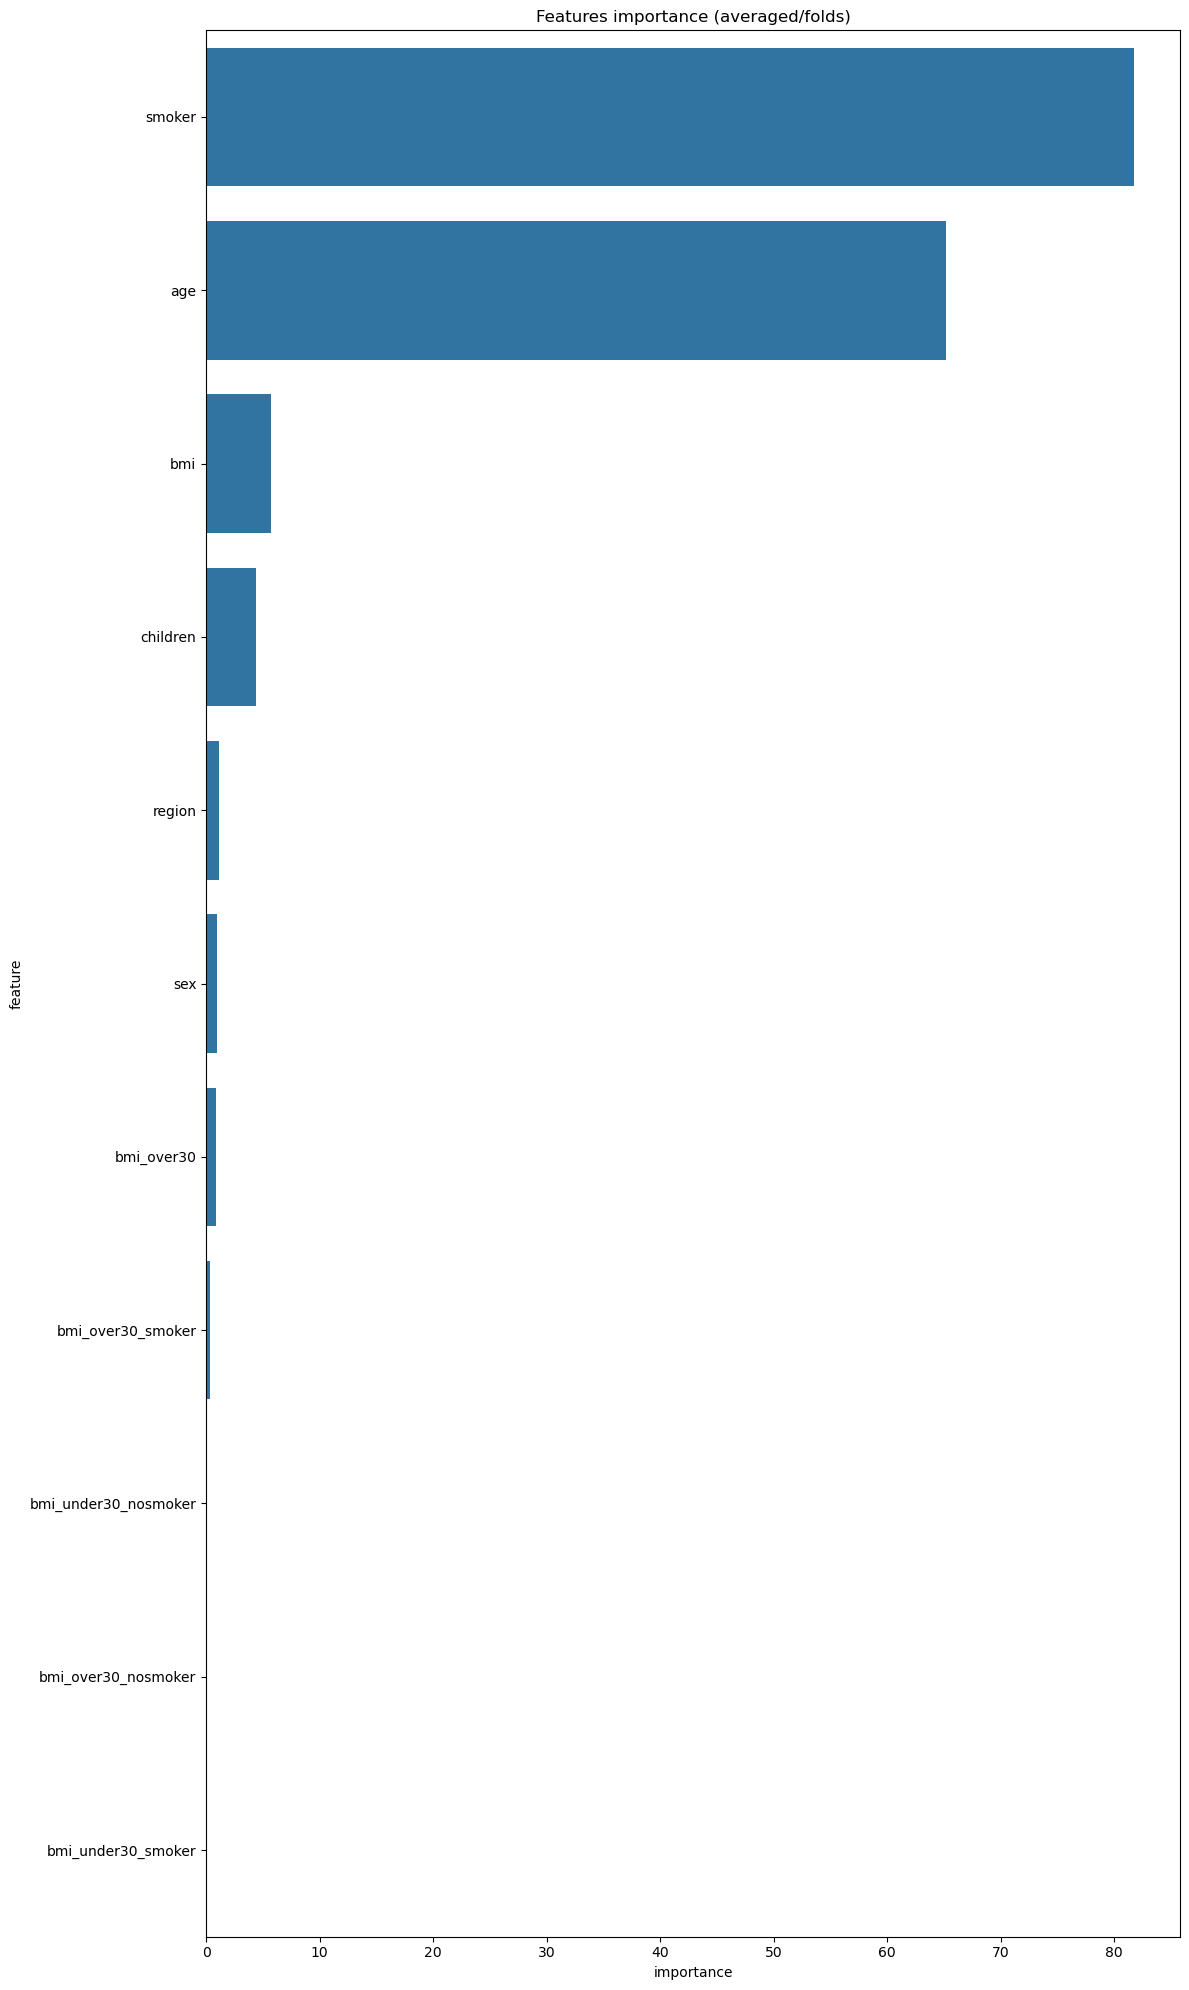

In [55]:
# lightgbm
param = {
    "loss_function":"rmse",
    'seed': CFG.seed,
}

model = TabularModel(model="LGB",
                     param=param,
                     n_fold=CFG.n_fold,
                     train_df=df,
                     num_features=num_features,
                     cat_features=cat_features,
                     target_col='charges',
                     num_class=1,
                     output_dir='gbdt/model/',
                     objective='regression')

# モデルのパラメータをoptunaで最適化
model.optimize_param(df, n_trials=10)
print(f"model.param: {model.param}")

# 学習（modelとlogファイルができる）
model.train(model.param, df)

# 特徴量重要度を可視化
model.show_feature_importance(figsize=(12, 20))

In [62]:
param = model.param
param

{'loss_function': 'rmse',
 'seed': 42,
 'subsample': 0.8283376813150221,
 'subsample_freq': 1,
 'reg_alpha': 0.15741890047456641,
 'reg_lambda': 0.004042872735027332,
 'min_split_gain': 0.017718847354806822}

In [71]:
model = lgb.LGBMRegressor(**param)
model.fit(X_test,y_test)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2}")

[LightGBM] [Warning] Unknown parameter: criterion
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Unknown parameter: criterion
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000220 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 322
[LightGBM] [Info] Number of data points in the train set: 1338, number of used features: 11
[LightGBM] [Info] Start training from score 0.513801
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[start] param optimization
study_param: {'max_leaf_nodes': 375, 'n_estimators': 951, 'min_samples_split': 4, 'min_samples_leaf': 6}
===== Fold 0 =====
train: 856 valid: 214
Fold0 score: 0.110081
===== Fold 1 =====
train: 856 valid: 214
Fold1 score: 0.091401
===== Fold 2 =====
train: 856 valid: 214
Fold2 score: 0.086702
===== Fold 3 =====
train: 856 valid: 214
Fold3 score: 0.084807
===== Fold 4 =====
train: 856 valid: 214
Fold4 score: 0.102106
CV score: 0.095506
study_param: {'max_leaf_nodes': 157, 'n_estimators': 156, 'min_samples_split': 2, 'min_samples_leaf': 9}
===== Fold 0 =====
train: 856 valid: 214
Fold0 score: 0.109717
===== Fold 1 =====
train: 856 valid: 214
Fold1 score: 0.090838
===== Fold 2 =====
train: 856 valid: 214
Fold2 score: 0.086677
===== Fold 3 =====
train: 856 valid: 214
Fold3 score: 0.083668
===== Fold 4 =====
train: 856 valid: 214
Fold4 score: 0.102416
CV score: 0.095175
study_param: {'max_leaf_nodes': 602, 'n_estimators': 709, 'min_samples_split': 2, 'min_samples_

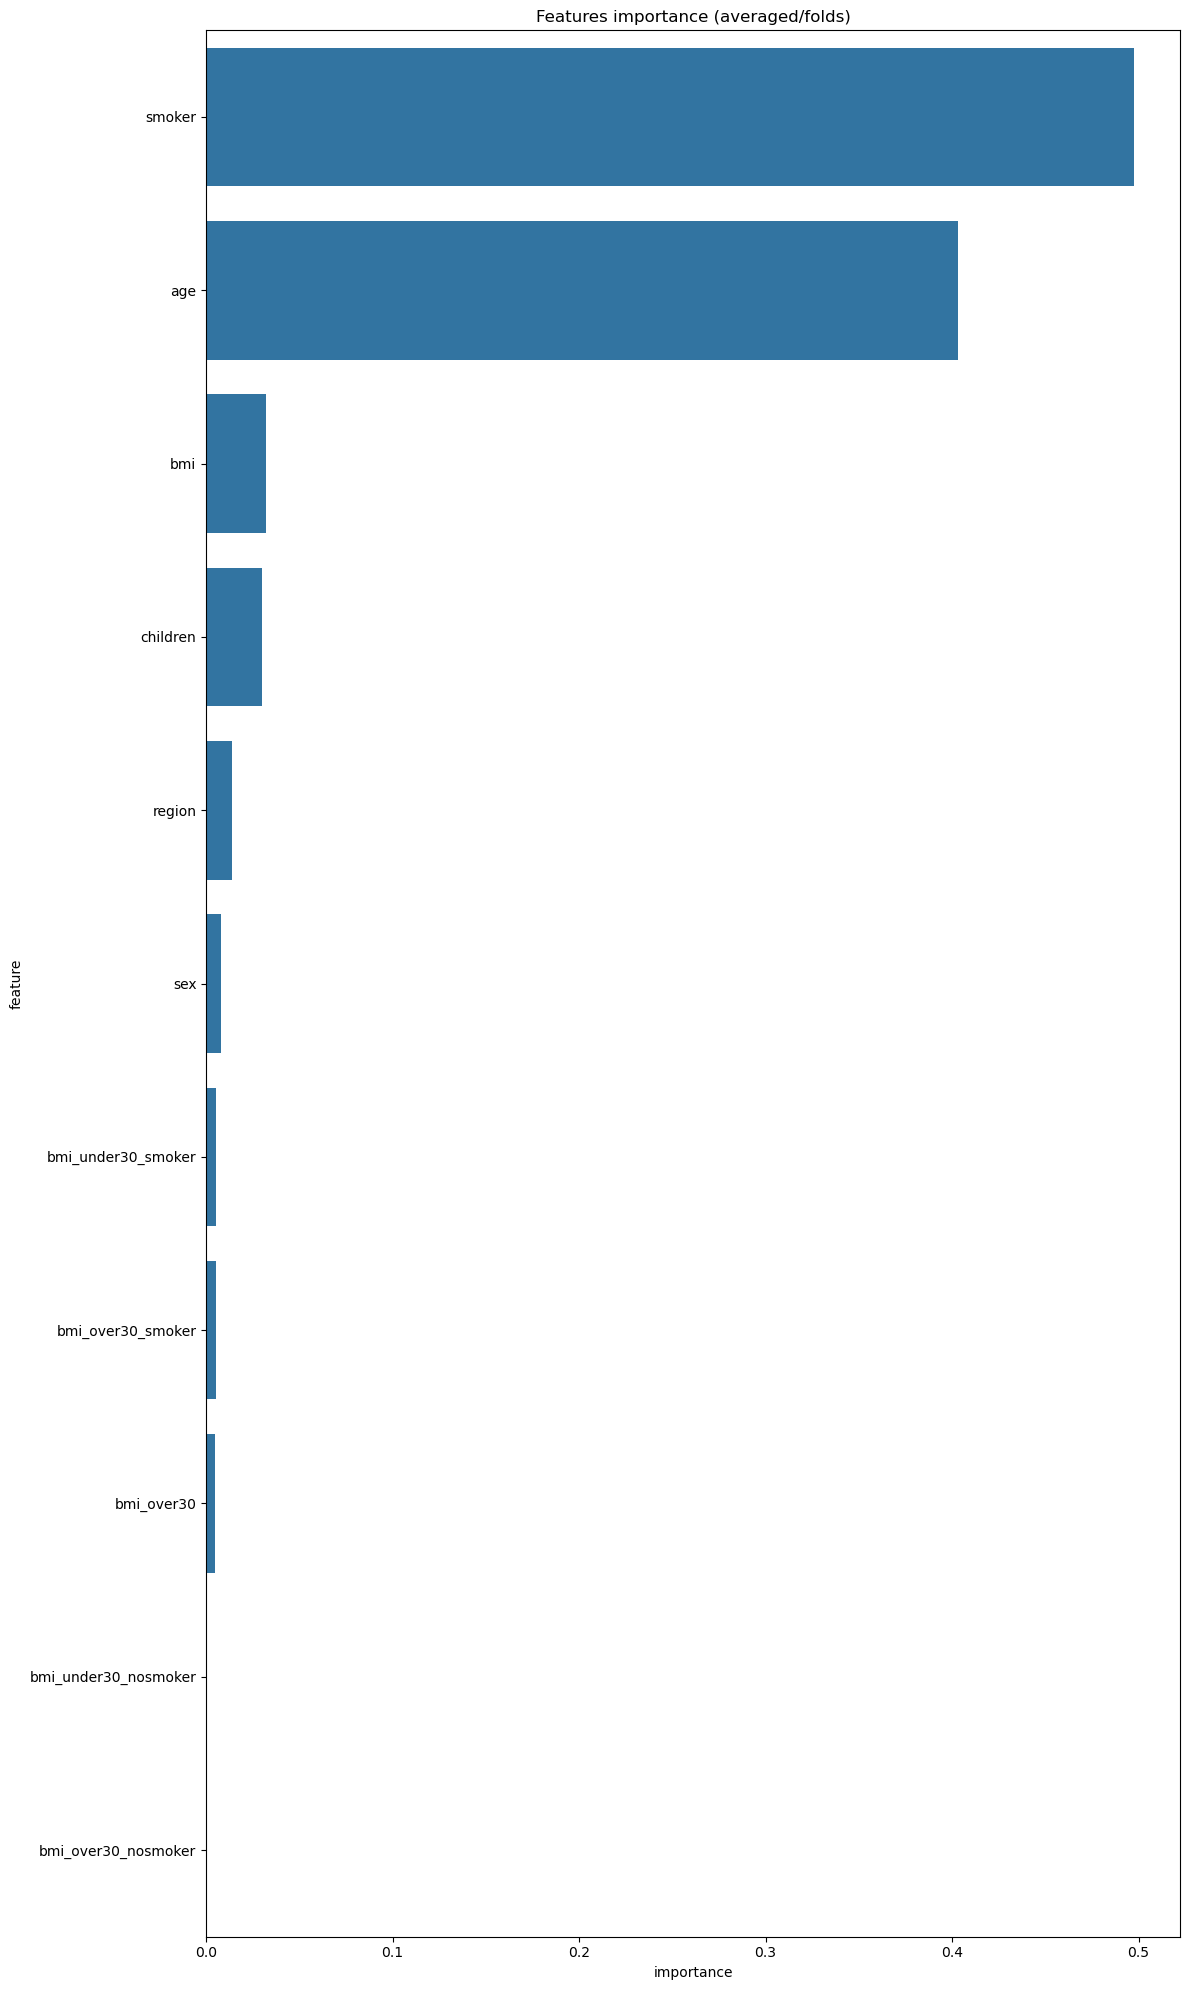

In [73]:
param = {
    "criterion":"squared_error",
    'max_depth': 10,
    'random_state': CFG.seed,
}

model = TabularModel(model="RF",
                     param=param,
                     n_fold=CFG.n_fold,
                     train_df=df,
                     num_features=num_features,
                     cat_features=cat_features,
                     target_col='charges',
                     num_class=1,
                     output_dir='gbdt/model/',
                     objective='regression')

# モデルのパラメータをoptunaで最適化
model.optimize_param(df, n_trials=10)
print(f"model.param: {model.param}")

# 学習（modelとlogファイルができる）
model.train(model.param, df)

# 特徴量重要度を可視化
model.show_feature_importance(figsize=(12, 20))

In [74]:
param = model.param
param

{'criterion': 'squared_error',
 'max_depth': 10,
 'random_state': 42,
 'max_leaf_nodes': 66,
 'n_estimators': 949,
 'min_samples_split': 5,
 'min_samples_leaf': 9}

In [75]:
model = RandomForestRegressor(**param)
model.fit(X_test,y_test)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2}")

RMSE: 0.08135592103861919
R2 Score: 0.8721211104093558


# 工夫点と考察

工夫点  
・前処理ではデータ探索を行い、bmiによるカテゴリカル変数を作成  
・LightGBM,RandomForestではoptuna(ベイズ最適化)を使用しパラメーターの探索を行った  
  
考察  
・最終的には決定係数はLightGBMが最も高くなった。  
・特徴量重要度として喫煙、年齢、bmiの順であった。  

課題  
・時間が足りずパラメーターの探索回数が少なくなってしまった。  
・決定木の可視化が間に合わず考察ができなかった。